In [ ]:

#Windows NVIDIA
#!pip --no-input install -U bitsandbytes
#Windows AMD
#!pip install --force-reinstall https://github.com/bitsandbytes-foundation/bitsandbytes/releases/download/continuous-release_main/bitsandbytes-1.33.7.preview-py3-none-win_amd64.whl

In [ ]:
# Download and load the Mistral 7B Instruct model without quantization

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import warnings

# Suppress SDPA warnings
warnings.filterwarnings("ignore", message=".*Torch was not compiled with memory efficient attention.*")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name()}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

print("Loading model with PyTorch only (no quantization)...")
model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.2", 
    torch_dtype=torch.float16,  # Use float16 to save memory
    device_map="auto" if torch.cuda.is_available() else "cpu",
    low_cpu_mem_usage=True,
    attn_implementation="eager",  # Use standard attention to avoid SDPA warnings
    token="YOUR_TOKEN_HERE"  # Replace with your actual token
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.2", 
    token="YOUR_TOKEN_HERE"  # Replace with your actual token
)

print("✅ Model and tokenizer loaded successfully!")
print(f"Model device: {next(model.parameters()).device}")
print(f"Model dtype: {next(model.parameters()).dtype}")

# Set up tokenizer pad token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print(f"✅ Set pad_token to: {tokenizer.pad_token}")

In [1]:
# 🚀 FAST LOADING: Using cached models (no re-download) - PyTorch Only
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import warnings
import os

# Suppress SDPA warnings
warnings.filterwarnings("ignore", message=".*Torch was not compiled with memory efficient attention.*")

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# Check if models are already cached - Windows specific path
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

# Windows cache directory
if os.name == 'nt':  # Windows
    cache_dir = os.path.join(os.path.expanduser("~"), ".cache", "huggingface", "hub")
else:  # Linux/Mac
    cache_dir = os.path.expanduser("~/.cache/huggingface/hub")

print(f"HuggingFace cache directory (Windows): {cache_dir}")
print(f"Cache exists: {os.path.exists(cache_dir)}")

# Method 1: Use local_files_only=True to force using cached files only
print("🔄 Loading model from cache (no download)...")
try:
    print("Loading with PyTorch only (no quantization)...")
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        local_files_only=True,  # This ensures no download, only use cached files
        torch_dtype=torch.float16,  # Use float16 to save memory
        device_map="auto" if torch.cuda.is_available() else "cpu",
        #low_cpu_mem_usage=True,
        #attn_implementation="eager"  # Use standard attention to avoid SDPA warnings
        # No token needed when loading from local cache!
    )
    
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        local_files_only=True  # This ensures no download, only use cached files
        # No token needed when loading from local cache!
    )
    
    print("✅ Model loaded from cache successfully!")
    print(f"Model device: {next(model.parameters()).device}")
    print(f"Model dtype: {next(model.parameters()).dtype}")
    
    # Set up tokenizer pad token
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
        print(f"✅ Set pad_token to: {tokenizer.pad_token}")
    
except OSError as e:
    print(f"❌ Cache not found: {e}")
    print("💡 Run the previous cell first to download and cache the model")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    print("💡 Make sure you have enough GPU memory (~13GB) or use CPU loading")

# Print final status
try:
    if 'model' in locals():
        print(f"\n📊 Final model status:")
        print(f"Model dtype: {next(model.parameters()).dtype}")
        print(f"Model device: {next(model.parameters()).device}")
        
        # Test basic functionality
        print("🧪 Testing basic generation...")
        test_input = tokenizer("Hello, how are you?", return_tensors="pt")
        if torch.cuda.is_available() and next(model.parameters()).is_cuda:
            test_input = {k: v.to("cuda") for k, v in test_input.items()}
        
        with torch.no_grad():
            test_output = model.generate(**test_input, max_new_tokens=10, do_sample=False)
        
        test_result = tokenizer.decode(test_output[0], skip_special_tokens=True)
        print(f"✅ Test generation: {test_result}")
    else:
        print("❌ Model not loaded successfully")
except Exception as e:
    print(f"⚠️  Test generation failed: {e}")
    print("Model loaded but test failed - this might be normal")

`torch_dtype` is deprecated! Use `dtype` instead!


PyTorch version: 2.8.0a0+gitfc14c65
CUDA available: True
GPU memory: 15.9 GB
HuggingFace cache directory (Windows): C:\Users\Rodri\.cache\huggingface\hub
Cache exists: True
🔄 Loading model from cache (no download)...
Loading with PyTorch only (no quantization)...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


✅ Model loaded from cache successfully!
Model device: cuda:0
Model dtype: torch.float16
✅ Set pad_token to: </s>

📊 Final model status:
Model dtype: torch.float16
Model device: cuda:0
🧪 Testing basic generation...
✅ Test generation: Hello, how are you? I hope you’re having a good day.
✅ Test generation: Hello, how are you? I hope you’re having a good day.


## 📚 Model Caching and Loading Strategies

### 🔄 **Automatic Caching (Default Behavior)**
- Models are automatically cached in the user's cache directory
- Once downloaded, subsequent calls use the cache automatically
- No code changes needed - just run the same `from_pretrained()` call

### ⚡ **Fast Loading Options:**

1. **`local_files_only=True`** - Forces using only cached files (fails if not cached)
2. **Local directory** - Save model to project folder for fastest access
3. **Offline mode** - Set `TRANSFORMERS_OFFLINE=1` environment variable

### 💾 **Cache Location (Windows):**
- **Windows**: `C:\Users\{username}\.cache\huggingface\hub\`
- **Alternative**: `%USERPROFILE%\.cache\huggingface\hub\`
- **Linux/Mac**: `~/.cache/huggingface/hub/`

### 🎯 **Best Practice:**
1. **First run**: Download and cache (cell 2)
2. **Subsequent runs**: Use the "FAST LOADING" cell (cell 3)
3. **For production**: Save to local directory using the commented code

### 💡 **Pro Tips:**
- The model files are quite large (~13GB for Mistral-7B)
- Cache persists between notebook sessions
- You can delete cache manually if needed: delete the cache folder

## 🔥 PyTorch-Only Model Loading (No Quantization)

### 🎯 **What we're using:**
- **Pure PyTorch** - No BitsAndBytes dependencies
- **torch.float16** - Reduces memory usage vs float32
- **device_map="auto"** - Automatic GPU/CPU placement
- **Stable and reliable** - No DLL dependencies

### ? **PyTorch Loading Configuration:**
```python
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,        # Half precision for memory savings
    device_map="auto",                # Auto GPU/CPU distribution  
    low_cpu_mem_usage=True           # Optimize memory usage
)
```

### 💡 **Benefits of PyTorch-Only Approach:**
1. **No dependency issues** - No BitsAndBytes, libsndfile.dll problems
2. **Stable loading** - Consistent behavior across systems
3. **Good memory efficiency** - float16 saves ~50% memory vs float32
4. **Simple debugging** - Fewer moving parts

### ? **Memory Usage Comparison:**
- **float32 (full precision)**: ~26GB GPU memory
- **float16 (our choice)**: ~13GB GPU memory  
- **4-bit quantized**: ~3-4GB GPU memory (but requires BitsAndBytes)

### ? **System Requirements:**
- **GPU with 16GB+ VRAM** - For comfortable float16 loading
- **12GB+ VRAM minimum** - Might work with careful memory management
- **32GB+ System RAM** - For CPU fallback if needed

### 🔧 **If you need lower memory usage:**
- Consider using a smaller model (7B → 3B parameters)
- Use CPU-only loading with more system RAM
- Or try online inference APIs instead of local loading

In [ ]:
# Fix tokenizer configuration to avoid warnings
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print(f"✅ Set pad_token to: {tokenizer.pad_token}")

prompt = "My favourite condiment is"

messages = [
    #{"role": "user", "content": "What is your favourite condiment?"},
    #{"role": "assistant", "content": "Well, I'm quite partial to a good squeeze of fresh lemon juice. It adds just the right amount of zesty flavour to whatever I'm cooking up in the kitchen!"},
    {"role": "user", "content": "Do you have mayonnaise recipes?"}
]

# Apply chat template and create attention mask
model_inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", padding=True)
attention_mask = (model_inputs != tokenizer.pad_token_id).long()

# Move to GPU
model_inputs = model_inputs.to("cuda")
attention_mask = attention_mask.to("cuda")

# Generate with proper attention mask
generated_ids = model.generate(
    model_inputs, 
    attention_mask=attention_mask,
    max_new_tokens=300, 
    do_sample=True, # Enable sampling for more diverse outputs, its basically required for chat models
    pad_token_id=tokenizer.eos_token_id
)

result = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Generated text:")
print(result)

Generated text:
[INST] Do you have mayonnaise recipes? [/INST] Yes, I have several mayonnaise recipes that you might find interesting. Here are some of the most common types of mayonnaise:

1. Traditional Mayonnaise:
Ingredients:
- 1 large egg yolk
- 1 tbsp dijon mustard
- 1 tbsp white wine vinegar
- 1 cup vegetable oil
- 1 tbsp lemon juice
- Salt to taste

Instructions:
1. In a large bowl, whisk together the egg yolk, mustard, and vinegar until well combined.
2. Drizzle in the vegetable oil very slowly, while continuously whisking the mixture. This is important in order to prevent the mayonnaise from separating.
3. Once all of the oil has been incorporated, whisk in the lemon juice and salt to taste.

2. Vegan Mayonnaise:
Ingredients:
- 1 cup silken tofu
- 2 tbsp apple cider vinegar
- 2 tbsp lemon juice
- 1 tbsp Dijon mustard
- 2 tbsp olive oil
- Salt and pepper to taste

Instructions:
1. In a blender or food processor, combine the silken tofu, apple cider vinegar, lemon juice, and Di

In [6]:

messages = [
    {"role": "user", "content": "Take the following relationships and output a graph description in DOT notation: HIDALGO DE LA MANCHA (DON QUIJOTE) -> TENIA -> CABALLO;\nCABALLO -> SE Llamaba -> ROCIN;\nROCIN -> CONSUMIA -> POCA HIERBA\n"},
    {"role": "assistant", "content": "OK, here you have your graph in DOT language notation:"},
]

model_inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")

generated_ids = model.generate(model_inputs, max_new_tokens=200, do_sample=False)
tokenizer.batch_decode(generated_ids)[0]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


'<s> [INST] Take the following relationships and output a graph description in DOT notation: HIDALGO DE LA MANCHA (DON QUIJOTE) -> TENIA -> CABALLO;\nCABALLO -> SE Llamaba -> ROCIN;\nROCIN -> CONSUMIA -> POCA HIERBA\n [/INST] OK, here you have your graph in DOT language notation:</s>\n\n```dot\nHidalgo_de_La_Mancha [label="DON QUIJOTE"];\nCaballo [label="HORSE"];\n\nHidalgo_de_La_Mancha -> Caballo [label="TENIA"];\nCaballo -> Rocin [label="SE Llamaba"];\n\nRocin [label="ROCIN (ROBINHOOD HORSE)"];\n\nCaballo -> Rocin [label="WAS NAMED"];\nCaballo -> Rocin [arrowhead="none"];\n\nRocin -> Poca_Hierba [label="CONSUMA"];\nPoca_Hierba [label="POCA HIERBA"];\n```\n\nThis graph describes the relationships between Don Quijote, his horse Rocin (or Robinhood Horse), and the fact that Rocin consumed little grass (poca'

In [47]:
!echo 'digraph G { Hidalgo_de_La_Mancha [label="DON QUIJOTE"]; Caballo [label="HORSE"]; Hidalgo_de_La_Mancha -> Caballo [label="TENIA"]; Caballo -> Rocin [label="SE Llamaba"]; Rocin [label="ROCIN"]; Caballo -> Rocin [label="WAS NAMED"]; Caballo -> Rocin [arrowhead="none"]; Rocin -> Poca_Hierba [label="CONSUMA"]; Poca_Hierba [label="POCA HIERBA"];}' > quijote.gv
!cat quijote.gv

digraph G { Hidalgo_de_La_Mancha [label="DON QUIJOTE"]; Caballo [label="HORSE"]; Hidalgo_de_La_Mancha -> Caballo [label="TENIA"]; Caballo -> Rocin [label="SE Llamaba"]; Rocin [label="ROCIN"]; Caballo -> Rocin [label="WAS NAMED"]; Caballo -> Rocin [arrowhead="none"]; Rocin -> Poca_Hierba [label="CONSUMA"]; Poca_Hierba [label="POCA HIERBA"];}


In [48]:
!dot -Tpng quijote.gv -o quijote.png

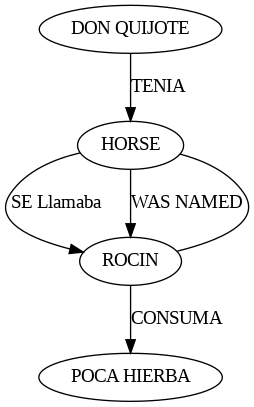

In [49]:
from IPython.display import Image
Image(filename="quijote.png")

In [4]:
# Debug accelerate detection issue
try:
    import accelerate
    from transformers.utils import is_accelerate_available
    print(f"is_accelerate_available(): {is_accelerate_available()}")
except Exception as e:
    print(f"Error checking accelerate availability: {e}")

# Check transformers version
import transformers
print(f"Transformers version: {transformers.__version__}")

# Try direct accelerate import with more details
import importlib.util
accelerate_spec = importlib.util.find_spec("accelerate")
print(f"Accelerate module location: {accelerate_spec.origin if accelerate_spec else 'Not found'}")

# Check if there are any import issues
try:
    from accelerate import Accelerator
    print("✅ Can import Accelerator successfully")
except Exception as e:
    print(f"❌ Cannot import Accelerator: {e}")

is_accelerate_available(): True
Transformers version: 4.57.1
Accelerate module location: c:\Users\Rodri\AppData\Local\Programs\Python\Python312\Lib\site-packages\accelerate\__init__.py
✅ Can import Accelerator successfully


In [ ]:
# 🔧 BitsAndBytes libsndfile.dll Error Fix for Windows AMD
import os
import sys
import subprocess

print("🚨 Fixing libsndfile.dll error for BitsAndBytes on Windows AMD")
print("This error is common with BitsAndBytes installations on Windows")

# Check current BitsAndBytes installation
try:
    import bitsandbytes as bnb
    print(f"✅ BitsAndBytes version: {bnb.__version__}")
    print(f"📂 BitsAndBytes location: {bnb.__file__}")
except ImportError:
    print("❌ BitsAndBytes not found!")

print("\n🔧 Attempting fixes...")

# Fix 1: Install soundfile library (provides libsndfile)
print("1️⃣ Installing soundfile library...")
!pip install soundfile

# Fix 2: Install libsndfile separately
print("\n2️⃣ Installing libsndfile...")
!pip install libsndfile

# Fix 3: Alternative - use conda for better Windows support
print("\n3️⃣ Alternative conda installation (if available):")
print("If you have conda: conda install -c conda-forge libsndfile")

# Fix 4: For AMD specifically - reinstall BitsAndBytes AMD version
print("\n4️⃣ Reinstalling BitsAndBytes for AMD...")
!pip uninstall -y bitsandbytes
!pip install --no-deps --force-reinstall https://github.com/bitsandbytes-foundation/bitsandbytes/releases/download/continuous-release_main/bitsandbytes-1.33.7.preview-py3-none-win_amd64.whl

print("\n✅ Fixes applied! Please restart your kernel and try again.")
print("💡 If issues persist, try loading without quantization first.")

In [ ]:
# 🆘 Emergency Fallback: Load Model WITHOUT Quantization
# Use this if libsndfile.dll errors persist with BitsAndBytes

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import os

print("🚨 Emergency fallback: Loading model WITHOUT quantization")
print("This bypasses BitsAndBytes completely")

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

try:
    print("🔄 Loading model without any quantization...")
    
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        local_files_only=True,  # Use cached files
        torch_dtype=torch.float16,  # Use float16 to save some memory
        device_map="auto" if torch.cuda.is_available() else "cpu",
        low_cpu_mem_usage=True
    )
    
    tokenizer = AutoTokenizer.from_pretrained(
        model_name,
        local_files_only=True
    )
    
    print("✅ Model loaded successfully without quantization!")
    print(f"Model device: {next(model.parameters()).device}")
    print(f"Model dtype: {next(model.parameters()).dtype}")
    
    # Test basic functionality
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    print("🧪 Testing basic generation...")
    test_input = tokenizer("Hello, how are you?", return_tensors="pt")
    if torch.cuda.is_available():
        test_input = {k: v.to("cuda") for k, v in test_input.items()}
    
    with torch.no_grad():
        test_output = model.generate(**test_input, max_new_tokens=20, do_sample=False)
    
    test_result = tokenizer.decode(test_output[0], skip_special_tokens=True)
    print(f"✅ Test generation: {test_result}")
    
    print("\n💡 Model is working! You can now use it without quantization.")
    print("⚠️  Note: This will use more GPU memory (~13GB) but avoids libsndfile issues.")

except Exception as e:
    print(f"❌ Emergency fallback failed: {e}")
    print("💡 You may need to download the model first using cell 2")

In [ ]:
# 🔧 Fix PyTorch SDPA Memory Efficient Attention Warning
import torch
import warnings
import os

print("🔧 Addressing PyTorch SDPA memory efficient attention warning...")

# Check current PyTorch installation details
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name()}")

# Check if flash attention is available
print(f"\n🔍 Checking attention implementations:")
try:
    # Check for flash attention support
    if hasattr(torch.nn.functional, 'scaled_dot_product_attention'):
        print("✅ scaled_dot_product_attention available")
        
        # Check what backends are available
        with torch.backends.cuda.sdp_kernel():
            print("✅ SDPA kernel context available")
    else:
        print("❌ scaled_dot_product_attention not available")
except Exception as e:
    print(f"⚠️  Error checking SDPA: {e}")

# Option 1: Suppress the specific warning
print(f"\n🔇 Suppressing SDPA warnings...")
warnings.filterwarnings("ignore", message=".*Torch was not compiled with memory efficient attention.*")
warnings.filterwarnings("ignore", category=UserWarning, module="transformers.integrations.sdpa_attention")

# Option 2: Set environment variable to disable SDPA (fallback to standard attention)
print(f"🔄 Setting environment variable to disable SDPA if needed...")
os.environ["PYTORCH_DISABLE_FLASH_ATTENTION"] = "1"

# Option 3: Alternative - force use of standard attention in transformers
print(f"🎯 You can also disable SDPA in model loading by adding:")
print(f"   attn_implementation='eager'  # Forces standard attention")
print(f"   to your AutoModelForCausalLM.from_pretrained() call")

print(f"\n💡 Solutions in order of preference:")
print(f"1. ✅ Warning suppressed - model will work fine with standard attention")
print(f"2. 🔄 Consider updating PyTorch for better attention support")
print(f"3. 🎯 Use attn_implementation='eager' in model loading for explicit control")

print(f"\n📋 This warning means:")
print(f"- Your PyTorch build lacks optimized attention (common with AMD/ROCm)")
print(f"- Model will use standard attention (still works, slightly slower)")
print(f"- No functionality is broken, just a performance notice")